c:\Users\Admin\anaconda3\envs\session1_env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\Admin\anaconda3\envs\session1_env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\Admin\anaconda3\envs\session1_env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider incre

Mean squared error của tập test 0.3333333333333333
Alpha tối ưu được chọn bởi LassoCV: 1
Hệ số của các đặc trưng : [-0. -0. -0.]


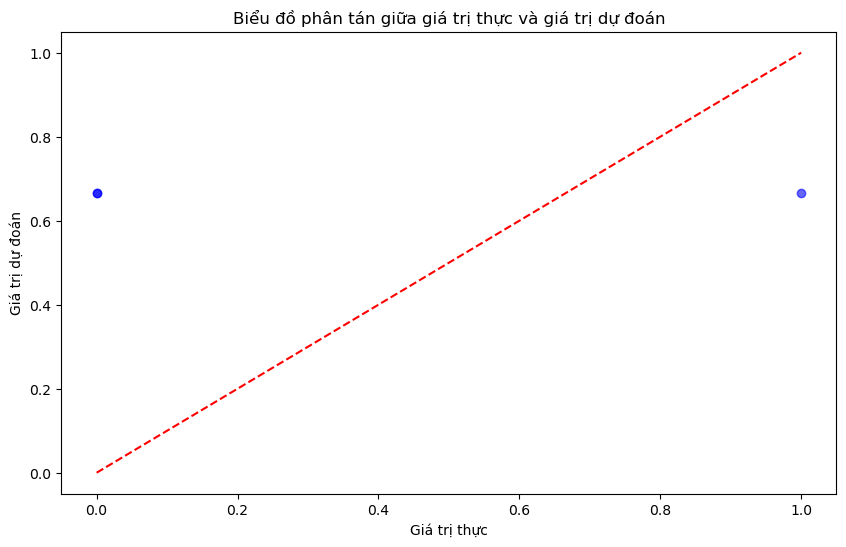


 Kết quả dự đoán trên tập test:
   Giá trị thực  Giá trị dự đoán liên tục   Giá trị dự đoán rời rạc
0             0                   0.666667                        1
1             1                   0.666667                        1
2             0                   0.666667                        1


In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd
df = pd.DataFrame({
    'Customer_ID': ['CUST000', 'CUST001', 'CUST002', 'CUST003', 'CUST004', 'CUST005'],
    'Tenure': [23 , 43 , 51 , 72 , 25 , 35],
    'Monthly_Charges': [49.85 , 100.7 , 97.33 , 101.38 , 52.22, 116.96],
    'Total_Charges': [1146.55, 4330.1 , 4963.83, 7299.36 , 1305.5 , 4093.6],
    'Churn': ['No', 'Yes', 'Yes', 'No', 'Yes', 'No']
})

le = LabelEncoder()
y = df['Churn'].values
X = df.drop(columns = ['Customer_ID', 'Churn'], axis = 1).values
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)


Lasso_model = Lasso()
param_grid = {'alpha': [0.001, 0.01 , 0.1 , 1 , 10 , 100]}
grid_search = GridSearchCV(Lasso_model , param_grid , cv = 3 , scoring = 'neg_mean_squared_error')

StandardScaler = StandardScaler() 
X_train_scaled = StandardScaler.fit_transform(X_train)
X_test_scaled = StandardScaler.transform(X_test)
grid_search.fit(X_train_scaled , y_train_enc)


best_lasso = grid_search.best_estimator_ #mô hình có alpha tốt nhất
y_pred_continuous = best_lasso.predict(X_test_scaled) #Lasso dự đoán giá trị liên tục
# Chuyển giá trị liên tục thành nhãn rời rạc (0 hoặc 1)
y_pred = np.round(np.clip(y_pred_continuous , 0 , 1)).astype(int)

mse = mean_squared_error(y_test_enc , y_pred_continuous) #đo sai số bình phương liên tục
accuracy = accuracy_score(y_test_enc , y_pred) #đo độ chính xác phân loại
print(f"Mean squared error của tập test {mse}")
print(f"Alpha tối ưu được chọn bởi LassoCV: {grid_search.best_params_['alpha']}")
print(f"Hệ số của các đặc trưng : {grid_search.best_estimator_.coef_}")

# Vẽ biểu đồ phân tán giữa giá trị thực và giá trị dự đoán
plt.figure(figsize=(10,6))
plt.scatter(y_test_enc , y_pred_continuous , color = 'blue', alpha = 0.6)
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel('Giá trị thực')
plt.ylabel('Giá trị dự đoán')
plt.title('Biểu đồ phân tán giữa giá trị thực và giá trị dự đoán')
plt.show()

result_df = pd.DataFrame({
    'Giá trị thực': y_test_enc, 
    'Giá trị dự đoán liên tục ': y_pred_continuous,
    'Giá trị dự đoán rời rạc': y_pred
})
print("\n Kết quả dự đoán trên tập test:")
print(result_df)


 Mean squared error của tập test với Ridge Regression: 0.024509319229021366


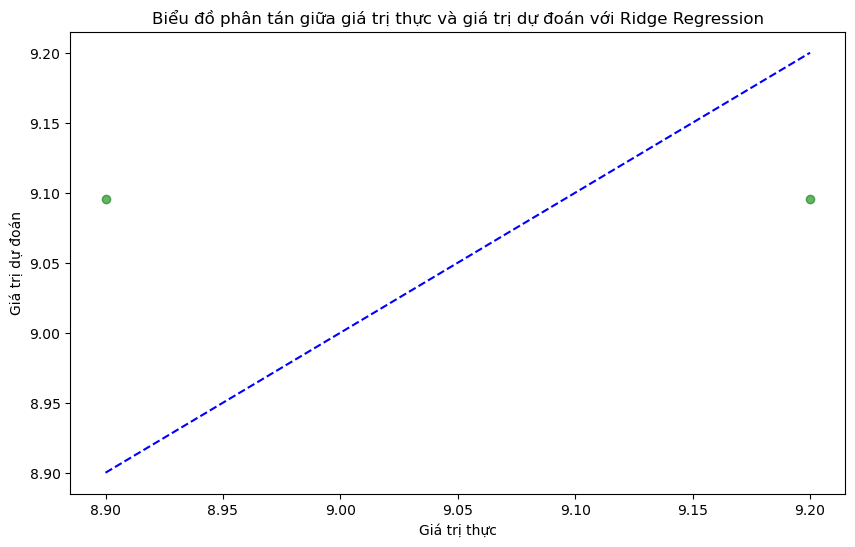

In [2]:
df2 = pd.DataFrame({
    'Genre': ['Drama', 'Crime,Drama', 'Action, Crime , Drama', 'Crime, Drama', 'Crime, Drama'],
    'Release_Year': [1994, 1972, 2008 , 1974 , 1957] ,
    'Runtime': ['142 min', '175 min', '152 min', '202 min', '96 min'],
    'Director': ['Frank Darabont', 'Francis Ford Coppola', 'Christopher Nolan', 'Francis Ford Coppola', 'Sidney Lumet'],
    'Ratings': [9.3, 9.2, 9.0, 9.0, 8.9]
})
y = df2['Ratings'].values
X = df2.drop(columns = ['Ratings'], axis = 1)
X_encoded = pd.get_dummies(X, drop_first = True).values
X_train , X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.4, random_state=42)\

X_train_scaled = StandardScaler.fit_transform(X_train)
X_test_scaled = StandardScaler.transform(X_test)
Ridge_model = Ridge()
param_grid_ridge = {'alpha': [0.001, 0.01 , 0.1 , 1 , 10 , 100]}
grid_search_ridge = GridSearchCV(Ridge_model , param_grid_ridge , cv = 3 , scoring = 'neg_mean_squared_error')
grid_search_ridge.fit(X_train_scaled , y_train)

y_pred_ridge = grid_search_ridge.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_test , y_pred_ridge)
print(f"\n Mean squared error của tập test với Ridge Regression: {mse_ridge}")

plt.figure(figsize=(10,6))
plt.scatter(y_test , y_pred_ridge , color = 'green', alpha = 0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color = 'blue', linestyle= '--')
plt.xlabel('Giá trị thực')
plt.ylabel('Giá trị dự đoán')
plt.title('Biểu đồ phân tán giữa giá trị thực và giá trị dự đoán với Ridge Regression')
plt.show()


 Mean squared error của tập test với ElasticNet Regression: 4.600339789947448

 Kết quả dự đoán trên tập test với ElasticNet Regression:
   Giá trị thực  Giá trị dự đoán
0            88        85.366325
1            75        72.737084
2            70        68.679398
Hệ số alpha tốt nhất : f{'alpha': 0.001, 'l1_ratio': 0.5}
Hệ số của các đặc trưng : [ 6.43983545  4.4308184   1.17928371  1.3173781  -0.38174795  0.46465387]


c:\Users\Admin\anaconda3\envs\session1_env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.004e-02, tolerance: 2.000e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\Admin\anaconda3\envs\session1_env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.776e-02, tolerance: 5.120e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\Admin\anaconda3\envs\session1_env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider incre

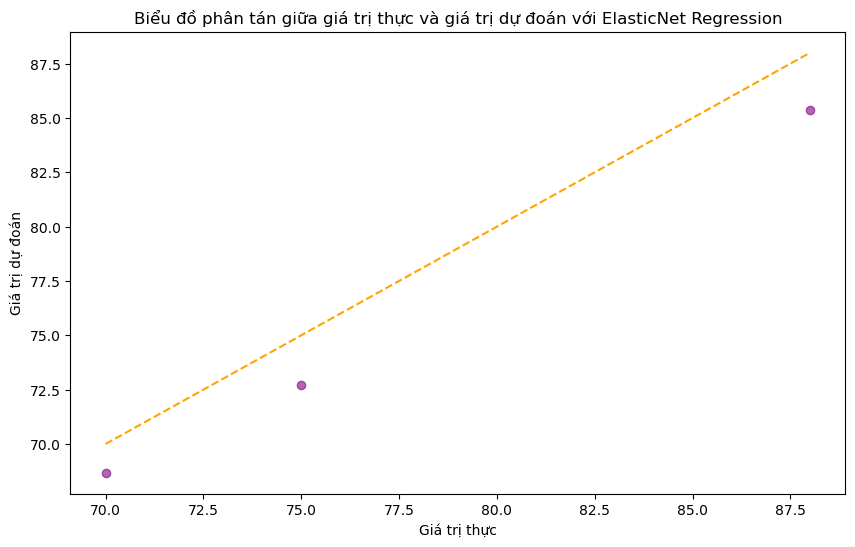

In [3]:
# Create DataFrame from Table 3.3
df_students = pd.DataFrame({
    'StudentID': ['STUD0000', 'STUD0001', 'STUD0002', 'STUD0003', 'STUD0004', 'STUD0005'],
    'Hours_Studied': [15, 10, 20, 5, 12, 8],
    'Attendance_Rate': [90, 80, 95, 60, 85, 75],
    'Previous_GPA': [3.5, 2.8, 3.9, 2.0, 3.2, 2.5],
    'Extracurricular': [1, 0, 1, 0, 1, 0],
    'Parental_Education': [4, 2, 5, 1, 3, 2],
    'Sleep_Hours': [8, 6, 7, 5, 7, 6],
    'Final_Grade': [88, 75, 92, 60, 80, 70]
})

X = df_students.drop(columns = ['StudentID', 'Final_Grade'], axis = 1).values
y = df_students['Final_Grade'].values
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
X_train_scaled = StandardScaler.fit_transform(X_train)
X_test_scaled = StandardScaler.transform(X_test)

ElasticNet_model = ElasticNet()
param_grid_elastic_net = {'alpha': [0.001, 0.01 , 0.1 , 1 , 10 , 100], 'l1_ratio': [0.1, 0.5, 0.9]}
grid_search_elastic = GridSearchCV(ElasticNet_model , param_grid_elastic_net , cv = 3 , scoring = 'neg_mean_squared_error')
grid_search_elastic.fit(X_train_scaled , y_train)

y_pred_elastic = grid_search_elastic.predict(X_test_scaled)
resuilt_df_elastic = pd.DataFrame({
    'Giá trị thực': y_test,
    'Giá trị dự đoán': y_pred_elastic
})
mse_elastic = mean_squared_error(y_test , y_pred_elastic)
print(f"\n Mean squared error của tập test với ElasticNet Regression: {mse_elastic}")
print("\n Kết quả dự đoán trên tập test với ElasticNet Regression:")
print(resuilt_df_elastic)
print(f"Hệ số alpha tốt nhất : f{grid_search_elastic.best_params_}")
print(f"Hệ số của các đặc trưng : {grid_search_elastic.best_estimator_.coef_}")


plt.figure(figsize=(10,6))
plt.scatter(y_test , y_pred_elastic , color = 'purple', alpha = 0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color = 'orange', linestyle= '--')
plt.xlabel('Giá trị thực')  
plt.ylabel('Giá trị dự đoán')
plt.title('Biểu đồ phân tán giữa giá trị thực và giá trị dự đoán với ElasticNet Regression')
plt.show()  